# Data Cleaning

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
# Update these paths to match your folder structure
DATA_DIR = "C:/Users/Gorata/IndabaX/Data_Raw" # folder containing the 5 CSV files

## 1. Baltic Dry Index

In [5]:
# Load Baltic Dry Index Dataset
bdi = pd.read_csv(f"{DATA_DIR}/01_baltic_dry_index_daily.csv", parse_dates=["Date"])

In [6]:
bdi.head()

,Date,BDI_Close,BDI_High,BDI_Low
0,2000-01-04,1320,1320,1320
1,2000-01-05,1329,1329,1329
2,2000-01-06,1351,1351,1351
3,2000-01-07,1368,1368,1368
4,2000-01-10,1376,1376,1376


In [7]:
bdi.tail()

,Date,BDI_Close,BDI_High,BDI_Low
5987,2023-12-18,2288,2288,2288
5988,2023-12-19,2219,2219,2219
5989,2023-12-20,2150,2150,2150
5990,2023-12-21,2087,2087,2087
5991,2023-12-22,2094,2094,2094


In [8]:
# Check dimensions of data
bdi.shape

(5992, 4)

In [9]:
# Check structure
bdi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5992 entries, 0 to 5991
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       5992 non-null   datetime64[ns]
 1   BDI_Close  5992 non-null   int64         
 2   BDI_High   5992 non-null   int64         
 3   BDI_Low    5992 non-null   int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 187.4 KB


No null values

In [10]:
# Check date range
print(f"Date range: {bdi['Date'].min().date()} to {bdi['Date'].max().date()}")

Date range: 2000-01-04 to 2023-12-22


In [11]:
# Check for duplicate rows
bdi.duplicated().sum()

3

In [12]:
# Drop duplicates
bdi = bdi.drop_duplicates()

In [13]:
# Check new dimensions
bdi.shape

(5989, 4)

In [14]:
# Check if dates are sorted
bdi['Date'].is_monotonic_increasing # Checks if dates are in ascending order. Returns "True" if this is the case.

True

In [15]:
# Check for duplicate dates
bdi['Date'].duplicated().sum()

0

In [16]:
# Summary statistics
bdi.describe()

,BDI_Close,BDI_High,BDI_Low
count,5989.000000,5989.000000,5989.000000
mean,2244.805978,2244.613959,2244.549507
std,1931.535463,1931.728391,1931.725691
min,290.000000,0.000000,0.000000
25%,1025.000000,1025.000000,1025.000000
50%,1559.000000,1559.000000,1559.000000
75%,2696.000000,2696.000000,2696.000000
max,11793.000000,11793.000000,11793.000000


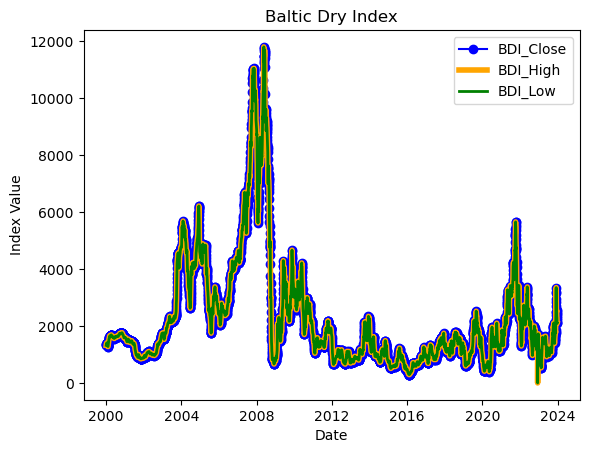

In [17]:
# Plot the time series
fig, ax = plt.subplots()

ax.plot(bdi['Date'], bdi['BDI_Close'], label='BDI_Close', color='blue', marker='o')
ax.plot(bdi['Date'], bdi['BDI_High'], label='BDI_High', color='orange', linewidth=4)
ax.plot(bdi['Date'], bdi['BDI_Low'], label='BDI_Low', color='green', linewidth=2)

ax.set_title('Baltic Dry Index')
ax.set_xlabel('Date')
ax.set_ylabel('Index Value')
ax.legend()  # Displays the labels assigned above

plt.show()

## 2. Brent Crude Oil Prices

In [20]:
# Load Brent Crude Oil prices dataset
brent = pd.read_csv(f"{DATA_DIR}/02_brent_crude_monthly.csv", parse_dates=["Date"])

In [21]:
brent.head()

,Date,Brent_USD_per_barrel
0,2000-01-15,25.51
1,2000-02-15,27.78
2,2000-03-15,27.49
3,2000-04-15,22.76
4,2000-05-15,27.74


In [22]:
brent.tail()

,Date,Brent_USD_per_barrel
283,2023-08-15,86.15
284,2023-09-15,93.72
285,2023-10-15,90.60
286,2023-11-15,82.94
287,2023-12-15,77.63


In [23]:
# Check dimensions of data
brent.shape

(288, 2)

In [24]:
# Check structure of data
brent.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288 entries, 0 to 287
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  288 non-null    datetime64[ns]
 1   Brent_USD_per_barrel  288 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 4.6 KB


No null values

In [25]:
# Check date range
print(f"Date range: {brent['Date'].min().date()} to {brent['Date'].max().date()}")

Date range: 2000-01-15 to 2023-12-15


In [26]:
# Check for duplicate rows
brent.duplicated().sum()

0

In [27]:
# Check if dates are sorted
brent['Date'].is_monotonic_increasing # Checks if dates are in ascending order. Returns "True" if this is the case.

True

In [28]:
# Check for duplicate dates
brent['Date'].duplicated().sum()

0

In [30]:
# Summary statistics
brent.describe()

,Brent_USD_per_barrel
count,288.000000
mean,66.114792
std,29.208779
min,18.380000
25%,43.230000
50%,63.940000
75%,85.497500
max,132.720000


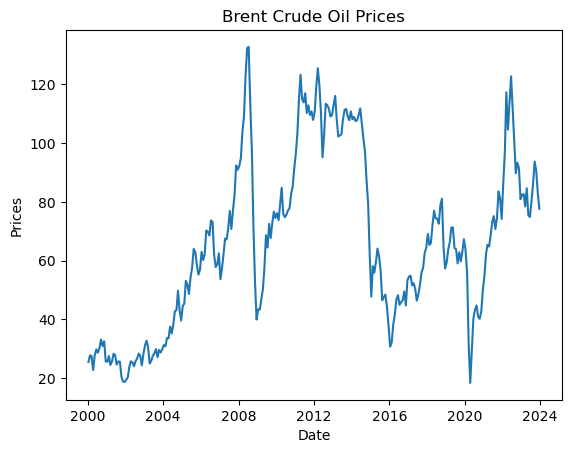

In [32]:
# Plot the time series
fig, ax = plt.subplots()

ax.plot(brent["Date"], brent["Brent_USD_per_barrel"])

ax.set_title("Brent Crude Oil Prices")
ax.set_xlabel("Date")
ax.set_ylabel("Prices")

plt.show()

The crude oil prices show sharp spikes around the 2008 recession and the COVID-19 pandemic.

## 3. Botswana Policy Rate

In [33]:
# Load policy rate dataset
pr = pd.read_csv(f"{DATA_DIR}/03_botswana_policy_rate.csv", parse_dates=["Date"])

In [34]:
pr.head()

,Date,policy_rate
0,2000-01-01,14.0
1,2000-02-01,14.0
2,2000-03-01,14.0
3,2000-04-01,14.0
4,2000-05-01,14.0


In [35]:
pr.tail()

,Date,policy_rate
283,2023-08-01,2.65
284,2023-09-01,2.65
285,2023-10-01,2.65
286,2023-11-01,2.65
287,2023-12-01,2.65


In [36]:
# Check dimensions
pr.shape

(288, 2)

In [37]:
# Check structure
pr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288 entries, 0 to 287
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         288 non-null    datetime64[ns]
 1   policy_rate  288 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 4.6 KB


No null values.

In [38]:
# Check date range
print(f"Date range: {pr['Date'].min().date()} to {pr['Date'].max().date()}")

Date range: 2000-01-01 to 2023-12-01


In [39]:
# Check for duplicate rows
pr.duplicated().sum()

0

In [40]:
# Check if dates are sorted
pr['Date'].is_monotonic_increasing # Checks if dates are in ascending order. Returns "True" if this is the case.

True

In [41]:
# Check for duplicate dates
pr['Date'].duplicated().sum()

0

In [42]:
# Summary statistics
pr.describe()

,policy_rate
count,288.000000
mean,11.586285
std,2.467477
min,1.650000
25%,12.000000
50%,12.000000
75%,12.000000
max,14.000000


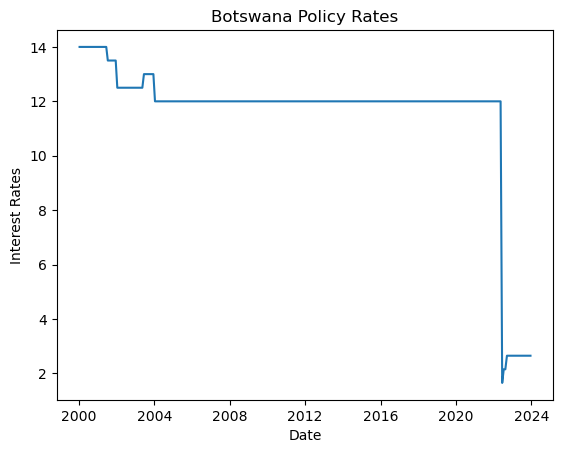

In [43]:
# Plot the time series
fig, ax = plt.subplots()

ax.plot(brent["Date"], pr["policy_rate"])

ax.set_title("Botswana Policy Rates")
ax.set_xlabel("Date")
ax.set_ylabel("Interest Rates")

plt.show()